In [69]:
import os
os.makedirs("outputs", exist_ok=True)

In [71]:
# Cell-1 see path that clearly points to geo_env
import sys
print(sys.executable)

/Users/swarajsingh/geo_env/bin/python


In [85]:
# Cell-2
import osmnx as ox

place_name = "Tikamgarh, Madhya Pradesh, India"
G = ox.graph_from_place(place_name, network_type='drive')


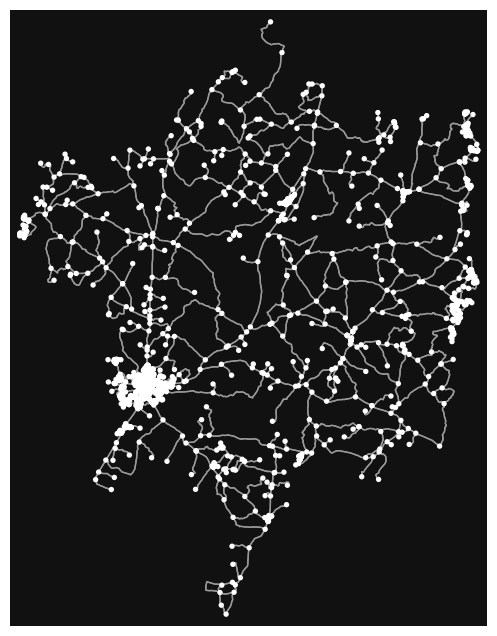

In [93]:
# Cell-3
#ox.plot_graph(G)
#fig.savefig("outputs/roads_networks.png", dpi=300, bbox_inches='tight')


fig, ax = ox.plot_graph(G)

fig.savefig("outputs/road_network.png", dpi=300, bbox_inches='tight')
plt.close(fig)

In [5]:
# Cell-4
import osmnx as ox

gdf = ox.geocode_to_gdf("Tikamgarh, Madhya Pradesh, India")
gdf

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((78.63137 24.96068, 78.63143 24.96061...",78.63137,24.436622,79.346354,25.27405,228143458,relation,1974089,24.85521,79.047255,boundary,administrative,10,0.481892,state_district,Tikamgarh,"Tikamgarh, Madhya Pradesh, India"


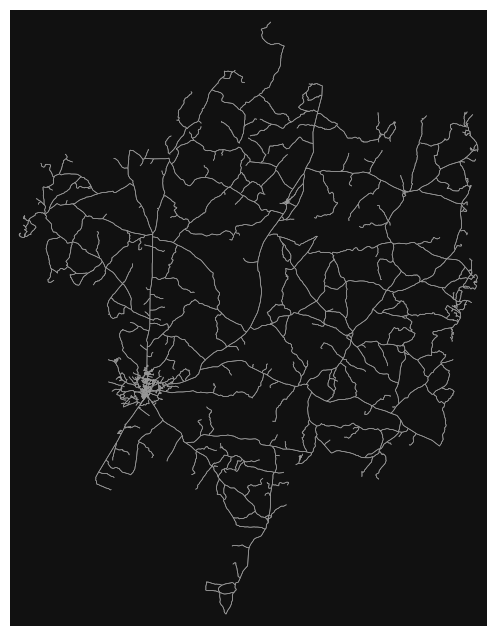

In [41]:
# Cell-5
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.5)
gdf.boundary.plot(ax=ax, edgecolor='red', linewidth=2)
fig.savefig("outputs/district_boundary.png", dpi=300, bbox_inches='tight')

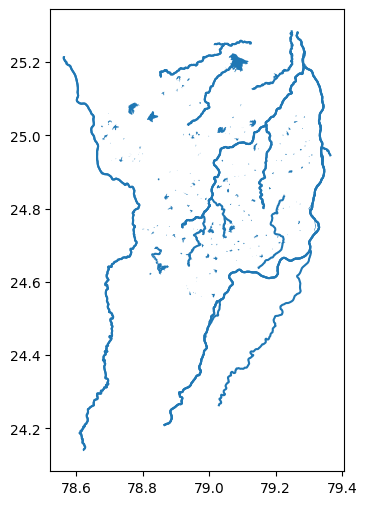

In [43]:
# Cell-6
tags = {'waterway': True, 'natural': 'water'}

water = ox.features_from_place(
    "Tikamgarh, Madhya Pradesh, India",
    tags
)

water.plot(figsize=(6,6))
plt.savefig("outputs/water_bodies.png", dpi=300, bbox_inches='tight')

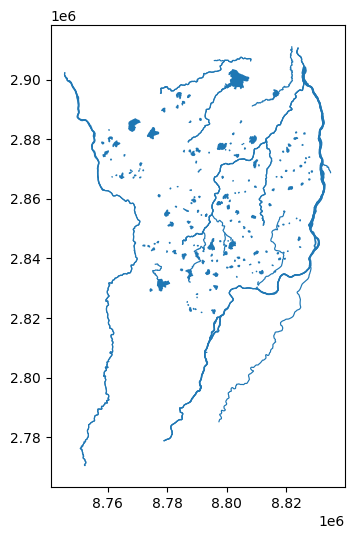

In [45]:
# Cell-7
# To ensure projected CRS (meters, not degrees)
water_proj = water.to_crs(epsg=3857)

# Creating 400m buffer around water bodies
water_buffer = water_proj.buffer(200)

# Convert back to GeoDataFrame
water_buffer = water_proj.copy()
water_buffer['geometry'] = water_proj.buffer(200)

# Plot to verify
water_buffer.plot(figsize=(6,6))
plt.savefig("outputs/water_buffer.png", dpi=300, bbox_inches='tight')

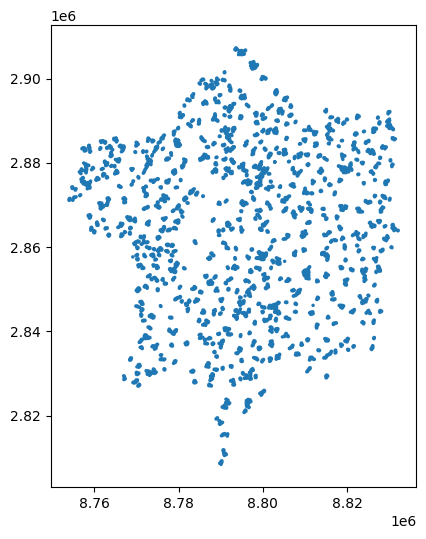

In [47]:
# Cell-8
# Get built-up / settlement features
tags = {'landuse': 'residential', 'building': True}

buildings = ox.features_from_place(
    "Tikamgarh, Madhya Pradesh, India",
    tags
)

# Project to meters
buildings_proj = buildings.to_crs(epsg=3857)

# Create 400m buffer for habitable spaces buildings etc.
pop_buffer = buildings_proj.buffer(400)

# Convert to GeoDataFrame
pop_buffer = buildings_proj.copy()
pop_buffer['geometry'] = buildings_proj.buffer(400)

# Plot
pop_buffer.plot(figsize=(6,6))
plt.savefig("outputs/settlement_buffer.png", dpi=300, bbox_inches='tight')

/var/folders/2k/fcnkctk90cldjrp98y7svp7w0000gn/T/ipykernel_53085/784571738.py:11: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  combined_exclusion = combined_exclusion.unary_union


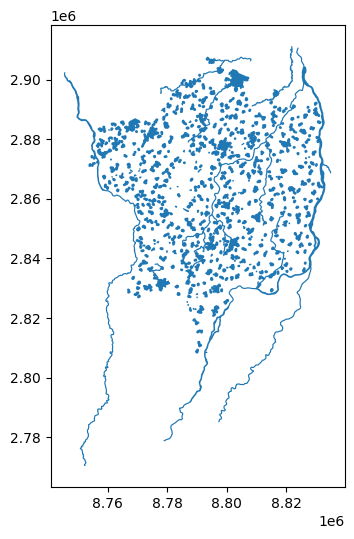

In [53]:
# Cell-9
import geopandas as gpd

# Combine both buffers
combined_exclusion = gpd.GeoSeries(
    list(water_buffer.geometry) + list(pop_buffer.geometry),
    crs=water_buffer.crs
)

# Dissolve into single geometry
combined_exclusion = combined_exclusion.unary_union

# Convert to GeoDataFrame
combined_exclusion = gpd.GeoDataFrame(geometry=[combined_exclusion], crs=water_buffer.crs)

# Plot
combined_exclusion.plot(figsize=(6,6))
plt.savefig("outputs/combined_exclusion.png", dpi=300, bbox_inches='tight')

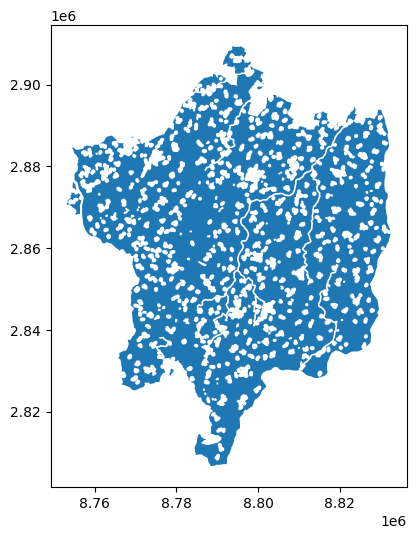

In [55]:
# Cell-10
# Get district boundary again and project
district = ox.geocode_to_gdf("Tikamgarh, Madhya Pradesh, India")
district_proj = district.to_crs(epsg=3857)

# Subtract exclusion from district
suitable_land = district_proj.geometry.iloc[0].difference(
    combined_exclusion.geometry.iloc[0]
)

# Convert to GeoDataFrame
suitable_land = gpd.GeoDataFrame(geometry=[suitable_land], crs=district_proj.crs)

# Plot
ax = suitable_land.plot(figsize=(6,6))
plt.savefig("outputs/suitable_land.png", dpi=300, bbox_inches='tight')

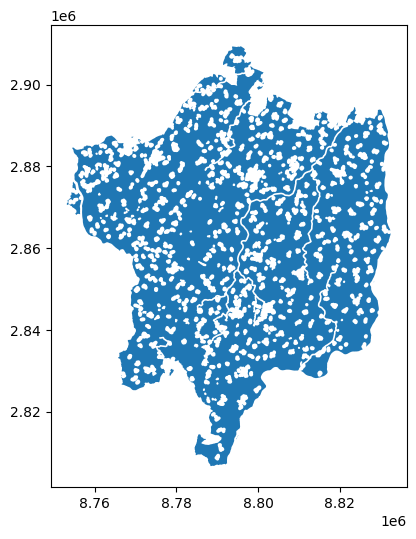

In [95]:
# Cell-11 
# Step: Generate candidate parcels and filter by size

# Break into individual parcels
suitable_land = suitable_land.explode(index_parts=False)

# Compute area (sq. meters)
suitable_land['area'] = suitable_land.geometry.area

# Apply realistic FSTP threshold
sites = suitable_land[suitable_land['area'] > 2500].copy()

# Plot
ax = sites.plot(figsize=(6,6))
plt.savefig("outputs/candidate_sites_raw.png", dpi=300, bbox_inches='tight')

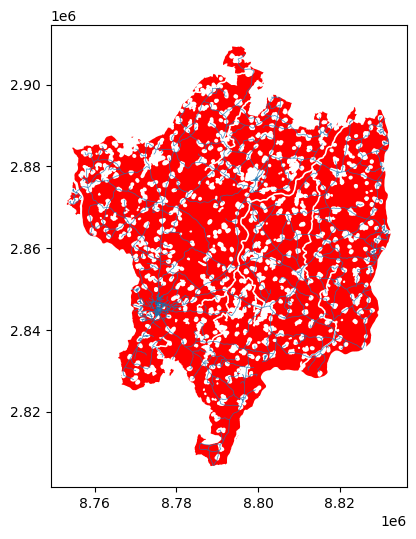

In [97]:
# Cell-12
# Get road network again (projected)
G = ox.graph_from_place("Tikamgarh, Madhya Pradesh, India", network_type='drive')
edges = ox.graph_to_gdfs(G, nodes=False).to_crs(epsg=3857)

# Plot candidate site + roads
ax = suitable_land.plot(figsize=(6,6), color='red')
edges.plot(ax=ax, linewidth=0.5, alpha=0.5)

plt.savefig("outputs/sites_with_roads_overlay.png", dpi=300, bbox_inches='tight')

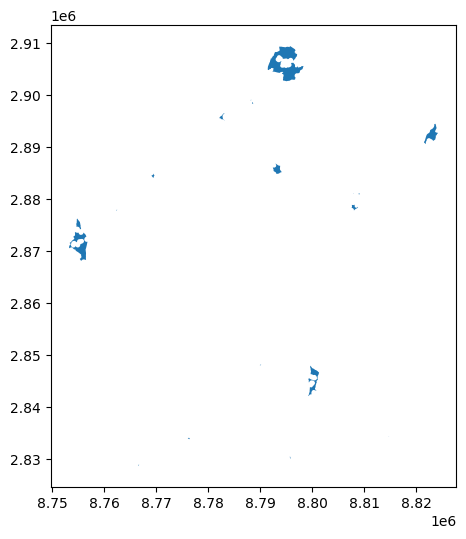

In [99]:
# Cell-13 b
# Keep only sites close to roads (within 1200m)
roads_union = edges.geometry.union_all()

sites['dist_to_road'] = sites.geometry.centroid.apply(lambda x: x.distance(roads_union))

sites = sites[sites['dist_to_road'] < 1200]

ax = sites.plot(figsize=(6,6))
plt.savefig("outputs/final_sites_filtered.png", dpi=300, bbox_inches='tight')

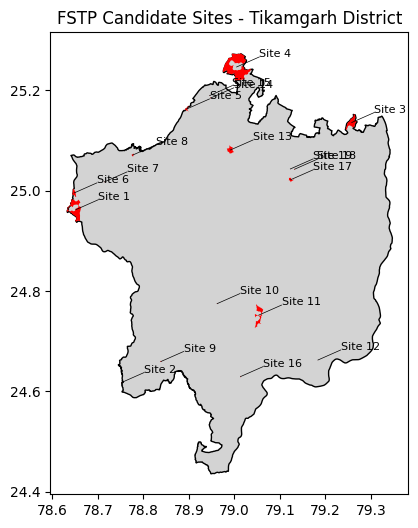

<Figure size 640x480 with 0 Axes>

In [101]:
# Cell-14
import matplotlib.pyplot as plt

# Convert to WGS84
district_wgs84 = district.to_crs(epsg=4326)
sites_wgs84 = sites.to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(6,6))

# Plot base
district_wgs84.plot(ax=ax, color='lightgrey', edgecolor='black')
sites_wgs84.plot(ax=ax, color='red')

# Loop through sites and label outside
for i, geom in enumerate(sites_wgs84.geometry):
    centroid = geom.centroid
    
    # Offset for label (move right side)
    x_offset = centroid.x + 0.05
    y_offset = centroid.y + 0.02
    
    # Draw line
    ax.plot([centroid.x, x_offset], [centroid.y, y_offset], color='black', linewidth=0.5)
    
    # Add label (simple numbering)
    ax.text(x_offset, y_offset, f"Site {i+1}", fontsize=8)

ax.set_title("FSTP Candidate Sites - Tikamgarh District")

plt.show()
plt.savefig("outputs/final_fstp_sites_map.png", dpi=300, bbox_inches='tight')

In [79]:
# Cell-16 (FIXED)

# Step 0: Create site IDs (this is missing)
sites = sites.reset_index(drop=True)
sites['site_id'] = ['Site ' + str(i+1) for i in range(len(sites))]

# Step 1: Compute centroid in projected CRS
sites_proj = sites.to_crs(epsg=3857)
centroids_proj = sites_proj.geometry.centroid

# Step 2: Convert to WGS84
centroids_wgs84 = gpd.GeoSeries(centroids_proj, crs=3857).to_crs(epsg=4326)

# Step 3: Extract lat-long
sites['latitude'] = centroids_wgs84.y
sites['longitude'] = centroids_wgs84.x

# Step 4: Clean output table
coords_table = sites[['site_id', 'latitude', 'longitude']]

coords_table
sites_wgs84.to_file("outputs/fstp_sites.geojson", driver="GeoJSON")